In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from pydantic import BaseModel
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import  add_messages
from langgraph.checkpoint.memory import InMemorySaver
from typing  import Annotated

In [3]:
class ChatState(BaseModel):
    messages:Annotated[list,add_messages]


In [4]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")


In [5]:
def chatbotNode(state:ChatState) -> ChatState:
    res = llm.invoke(state.messages)
    state.messages = [res]
    return state    

In [6]:
memory = InMemorySaver()

In [7]:
graph = StateGraph(ChatState)
graph.add_node("Chatbot",chatbotNode)
graph.add_edge(START,"Chatbot")
graph.add_edge("Chatbot",END)

In [8]:
graph = graph.compile(checkpointer=memory)

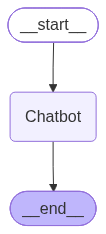

In [9]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [14]:
res = graph.invoke({"messages":[{"role":"user","content":"who i am ?"}]},{"configurable":{"thread_id":112}})
res["messages"][-1].text

"You are Dhaval! You just told me your name a moment ago. \n\nIs there anything else you'd like me to remember about you?"